In [9]:
#1.Import libraries
#2.Show files in folder with this file.
#3.Calculation of my own sensitivity map with Multi Ray Marching
#4.Calculation blurred maps
#5.Import own sensitivity map
#6.Testing on TOF reconstruction

In [3]:
import uproot
import awkward as ak
import numpy as np
from numba import njit, prange
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%matplotlib inline 

In [4]:
import os
print("Files in folder:", os.listdir('.'))

Files in folder: ['.ipynb_checkpoints', 'attenuated_sensitivity_raytracing10_it1.img', 'attenuation_implementation.ipynb', 'Attenuation_map_try.ipynb', 'attenuation_mumap.img', 'FBP.ipynb', 'geom.txt', 'medical.root', 'MLEM with new sens map sigma 2 multi.ipynb', 'MLEM with new sens map sigma 2.ipynb', 'MLEM with new sens map signa 2 grey scale.ipynb', 'MLEM_noт_tof_&_tof.ipynb', 'my_own_map.img', 'pydip', 'reconstruction_multi_siddon.npy', 'sensitivity_raytracing10_it1.img', 'test_umap_resampled.img', 'Untitled.ipynb']


Map successfully saved!
Data file: C:\essential\subjects\Licencjat\Raw\sens_map_own\my_own_map.img
Header: C:\essential\subjects\Licencjat\Raw\sens_map_own\my_own_map.hdr


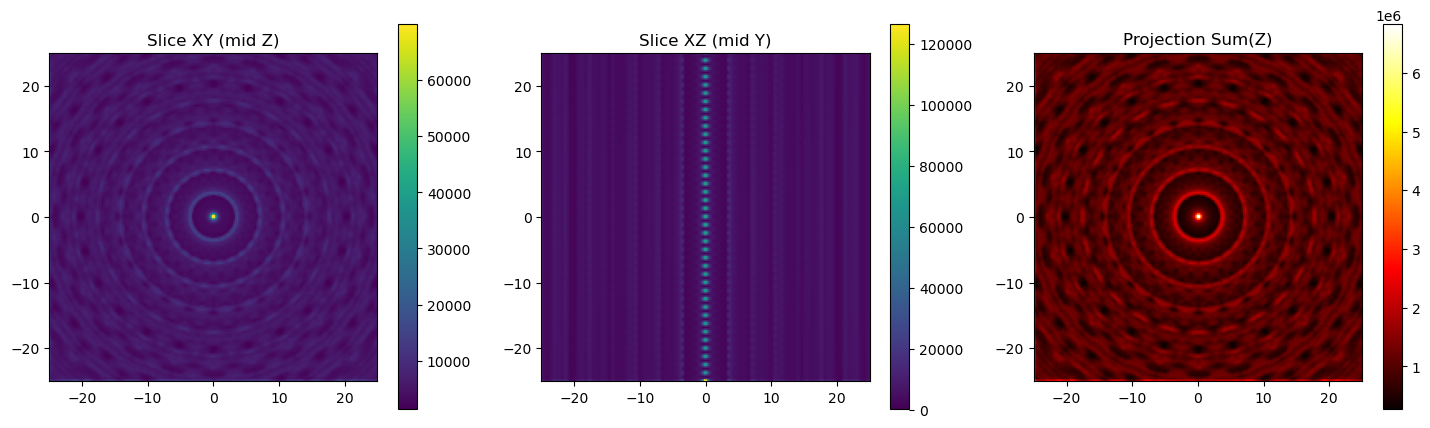

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
import itertools


XMIN, XMAX, DX = -25.0, 25.0, 0.25
YMIN, YMAX, DY = -25.0, 25.0, 0.25
ZMIN, ZMAX, DZ = -25.0, 25.0, 0.25

Nx = int((XMAX - XMIN) / DX)
Ny = int((YMAX - YMIN) / DY)
Nz = int((ZMAX - ZMIN) / DZ)

STEP_SIZE = 0.2

N_RAYS = 10
TUBE_RADIUS = 0.25

@njit(parallel=True, fastmath=True)
def calculate_sensitivity_map(x_det, y_det, z_det, Nx, Ny, Nz):
    sens = np.zeros((Nx, Ny, Nz), dtype=np.float32)
    n_detectors = len(x_det)
    
    for i in prange(0, n_detectors):
       for j in range(i + 1, n_detectors):
            x1, y1, z1 = x_det[i], y_det[i], z_det[i]
            x2, y2, z2 = x_det[j], y_det[j], z_det[j]
            
            vx = x2 - x1
            vy = y2 - y1
            vz = z2 - z1
            L = np.sqrt(vx**2 + vy**2 + vz**2)
            
            if L <= 0: continue

            nx, ny, nz = vx/L, vy/L, vz/L
            steps = int(L / STEP_SIZE)

            if abs(nx) > abs(ny):
                norm_u = np.sqrt(nx**2 + nz**2)
                ux, uy, uz = -nz/norm_u, 0.0, nx/norm_u
            else:
                norm_u = np.sqrt(ny**2 + nz**2)
                ux, uy, uz = 0.0, -nz/norm_u, ny/norm_u
                
            vx_ort = ny*uz - nz*uy
            vy_ort = nz*ux - nx*uz
            vz_ort = nx*uy - ny*ux
    
            s_j = 0.0
            for r in range(N_RAYS):
                if r == 0:
                    offset_u = 0.0
                    offset_v = 0.0
                else:
                    angle = 2.0 * np.pi * r / 9.0
                    offset_u = np.cos(angle) * TUBE_RADIUS
                    offset_v = np.sin(angle) * TUBE_RADIUS
                    
                x1_r = x1 + offset_u*ux + offset_v*vx_ort
                y1_r = y1 + offset_u*uy + offset_v*vy_ort
                z1_r = z1 + offset_u*uz + offset_v*vz_ort
                
                for s in range(steps):
                    curr_x = x1_r + nx * (s * STEP_SIZE)
                    curr_y = y1_r + ny * (s * STEP_SIZE)
                    curr_z = z1_r + nz * (s * STEP_SIZE)
                    idx_x = int((curr_x - XMIN) / DX)
                    idx_y = int((curr_y - YMIN) / DY)
                    idx_z = int((curr_z - ZMIN) / DZ)
                    if 0 <= idx_x < Nx and 0 <= idx_y < Ny and 0 <= idx_z < Nz:
                        sens[idx_x, idx_y, idx_z] += 1
                    
    return sens

geom_data = np.loadtxt("geom.txt", skiprows=1) 
    
x_det = geom_data[:, 0].astype(np.float32)
y_det = geom_data[:, 1].astype(np.float32)
z_det = geom_data[:, 2].astype(np.float32)
    

sensitivity = calculate_sensitivity_map(x_det, y_det, z_det, Nx, Ny, Nz)

sensitivity[sensitivity < 1e-6] = 1e-6 

save_directory = r"C:\essential\subjects\Licencjat\Raw\sens_map_own" 
base_filename = "my_own_map"


img_path = os.path.join(save_directory, f"{base_filename}.img")
hdr_path = os.path.join(save_directory, f"{base_filename}.hdr")


sens_export = sensitivity.astype(np.float32)
sens_export.flatten(order='F').tofile(img_path)


header_content = f"""!INTERFILE  :=
!imaging modality := other
!version of keys := 3.3
!total number of images := {Nz}
!matrix size [1] := {Nx}
!matrix size [2] := {Ny}
!matrix size [3] := {Nz}
!number format := short float
!number of bytes per pixel := 4
!name of data file := {base_filename}.img
"""

with open(hdr_path, "w", encoding="utf-8") as f:
    f.write(header_content)

print(f"Map successfully saved!")
print(f"Data file: {img_path}")
print(f"Header: {hdr_path}")


def plot_sensitivity(sens_map):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    mid_x, mid_y, mid_z = Nx // 2, Ny // 2, Nz // 2
    
    im0 = axes[0].imshow(sens_map[:, :, mid_z].T, origin='lower', extent=[XMIN, XMAX, YMIN, YMAX], cmap='viridis')
    axes[0].set_title("Slice XY (mid Z)")
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(sens_map[:, mid_y, :].T, origin='lower', extent=[XMIN, XMAX, ZMIN, ZMAX], cmap='viridis')
    axes[1].set_title("Slice XZ (mid Y)")
    plt.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(np.sum(sens_map, axis=2).T, origin='lower', extent=[XMIN, XMAX, YMIN, YMAX], cmap='hot')
    axes[2].set_title("Projection Sum(Z)")
    plt.colorbar(im2, ax=axes[2])
    
    plt.show()

plot_sensitivity(sensitivity)

In [5]:
import os
from scipy.ndimage import gaussian_filter

def plot_sensitivity(sens_map, title_suffix=""):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    mid_x, mid_y, mid_z = Nx // 2, Ny // 2, Nz // 2
    
    im0 = axes[0].imshow(sens_map[:, :, mid_z].T, origin='lower', extent=[XMIN, XMAX, YMIN, YMAX], cmap='viridis')
    axes[0].set_title(f"Slice XY (mid Z){title_suffix}")
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(sens_map[:, mid_y, :].T, origin='lower', extent=[XMIN, XMAX, ZMIN, ZMAX], cmap='viridis')
    axes[1].set_title(f"Slice XZ (mid Y){title_suffix}")
    plt.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(np.sum(sens_map, axis=2).T, origin='lower', extent=[XMIN, XMAX, YMIN, YMAX], cmap='hot')
    axes[2].set_title(f"Projection Sum(Z){title_suffix}")
    plt.colorbar(im2, ax=axes[2])
    
    plt.show()


print("Displaying original map...")
plot_sensitivity(sensitivity, title_suffix=" (Original)")


sigmas = [6.0, 7.0, 8.0, 10.0]

for sigma in sigmas:
    print(f"\nApplying Gaussian blur with sigma = {sigma}...")
    
    blurred_sensitivity = gaussian_filter(sensitivity, sigma=sigma)
    
    blurred_sensitivity[blurred_sensitivity < 1e-6] = 1e-6 
    
    base_filename_blur = f"{base_filename}_sigma_{sigma}"
    img_path = os.path.join(save_directory, f"{base_filename_blur}.img")
    
    sens_export = blurred_sensitivity.astype(np.float32)
    sens_export.flatten(order='F').tofile(img_path)
        
    print(f"Map with sigma={sigma} successfully saved: {img_path}")
    
    plot_sensitivity(blurred_sensitivity, title_suffix=f" (Sigma: {sigma})")

Displaying original map...


NameError: name 'sensitivity' is not defined

In [8]:
sensitivity = np.fromfile(r'C:\essential\subjects\Licencjat\Raw\sens_map_own\my_own_map_sigma_7.0.img', dtype='float32').reshape((200, 200, 200), order='F')
#sensitivity = np.fromfile(my_own_map.img, dtype='float32').reshape((200, 200, 200), order='F')
max_sens = np.max(sensitivity)
if max_sens > 0:
    sensitivity /= max_sens

sensitivity[sensitivity < 1e-12] = 1e-12

Grid: 200x200x200
TOF Sigma X: 3.822 cm
Reading file medical.root...
Loaded: 20809861 events
Starting TOF MLEM with (12 iterations)...
  -> Iteration 1... 

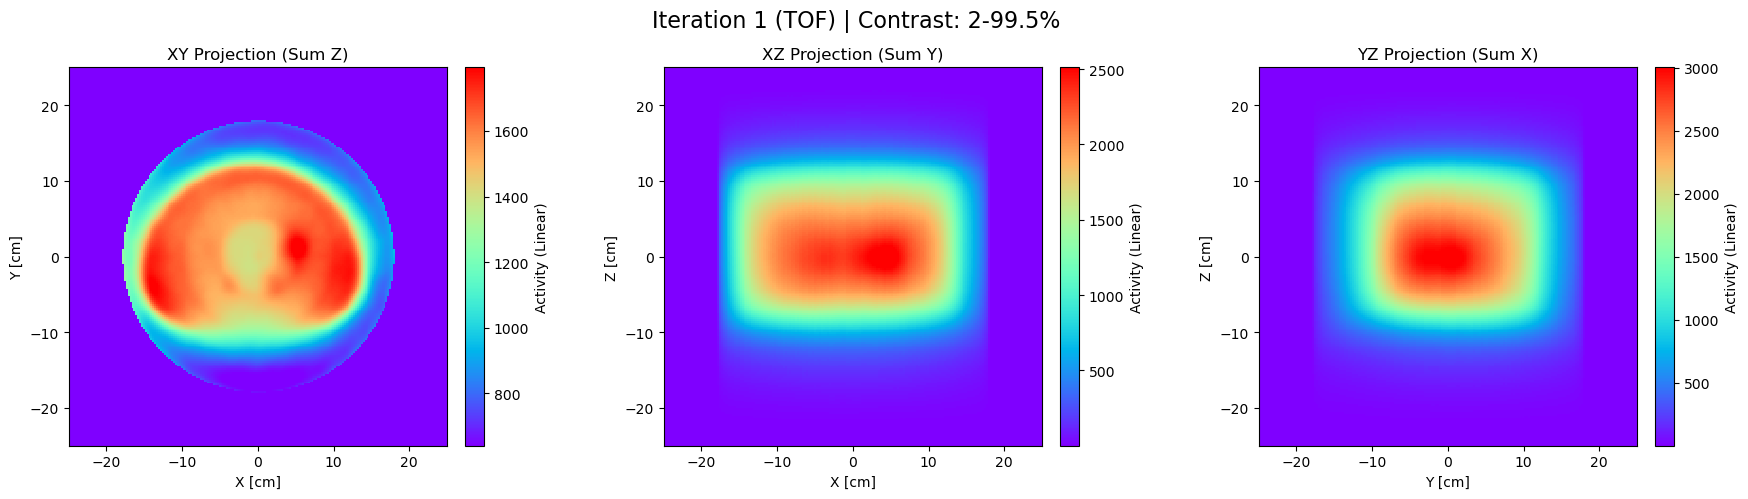

Done
  -> Iteration 2... 

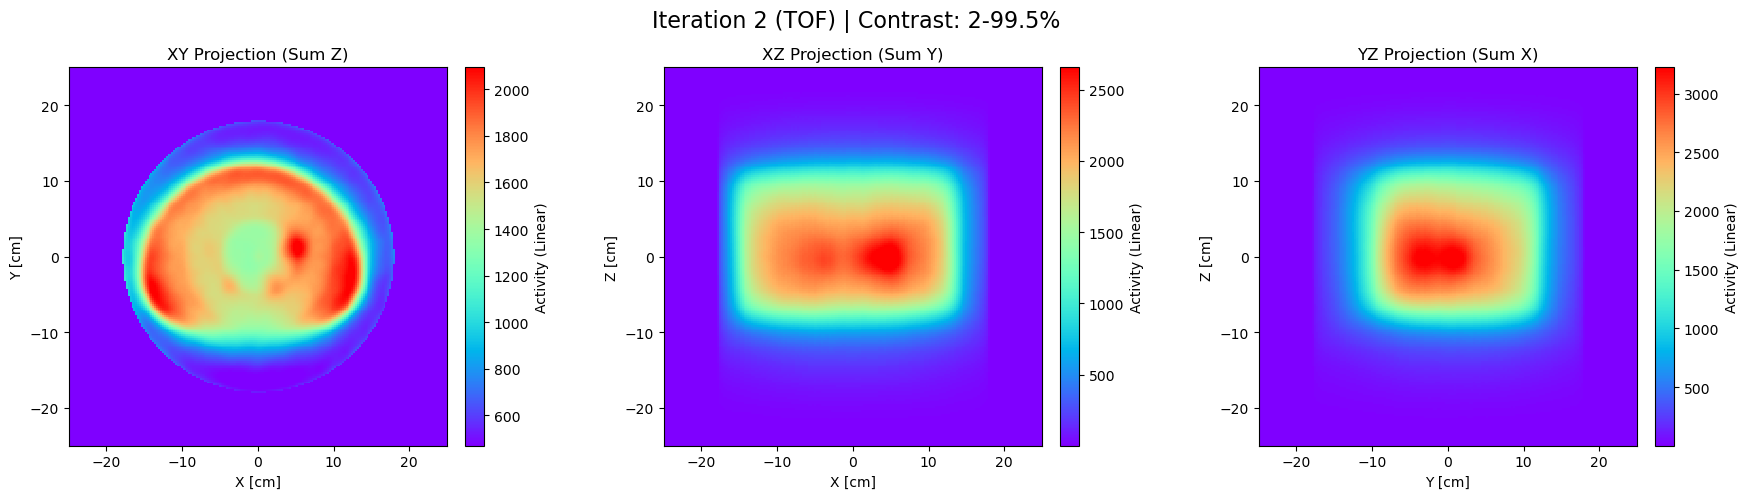

Done
  -> Iteration 3... 

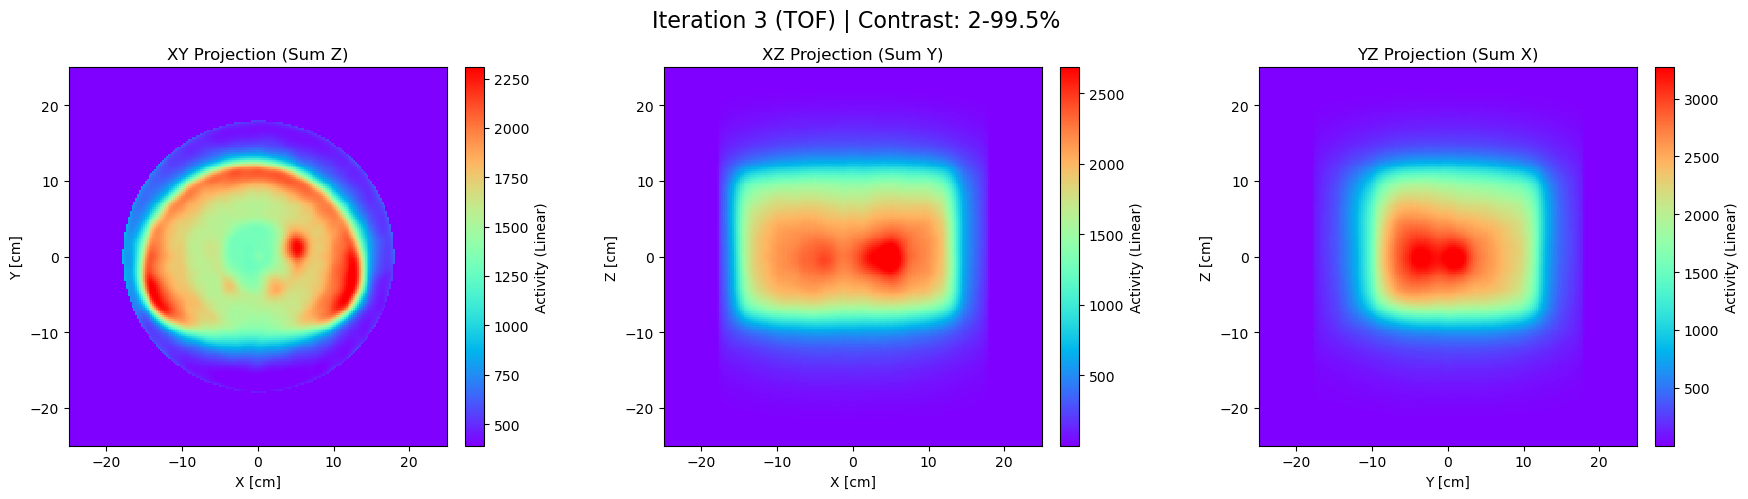

Done
  -> Iteration 4... 

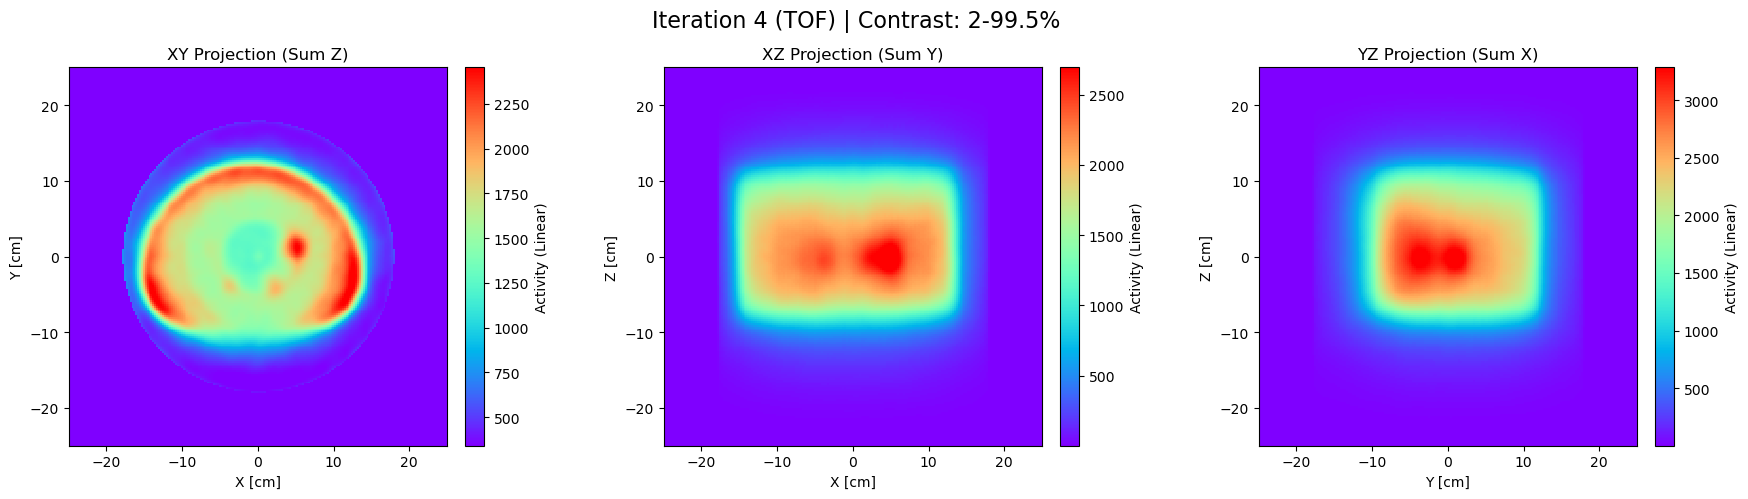

Done
  -> Iteration 5... 

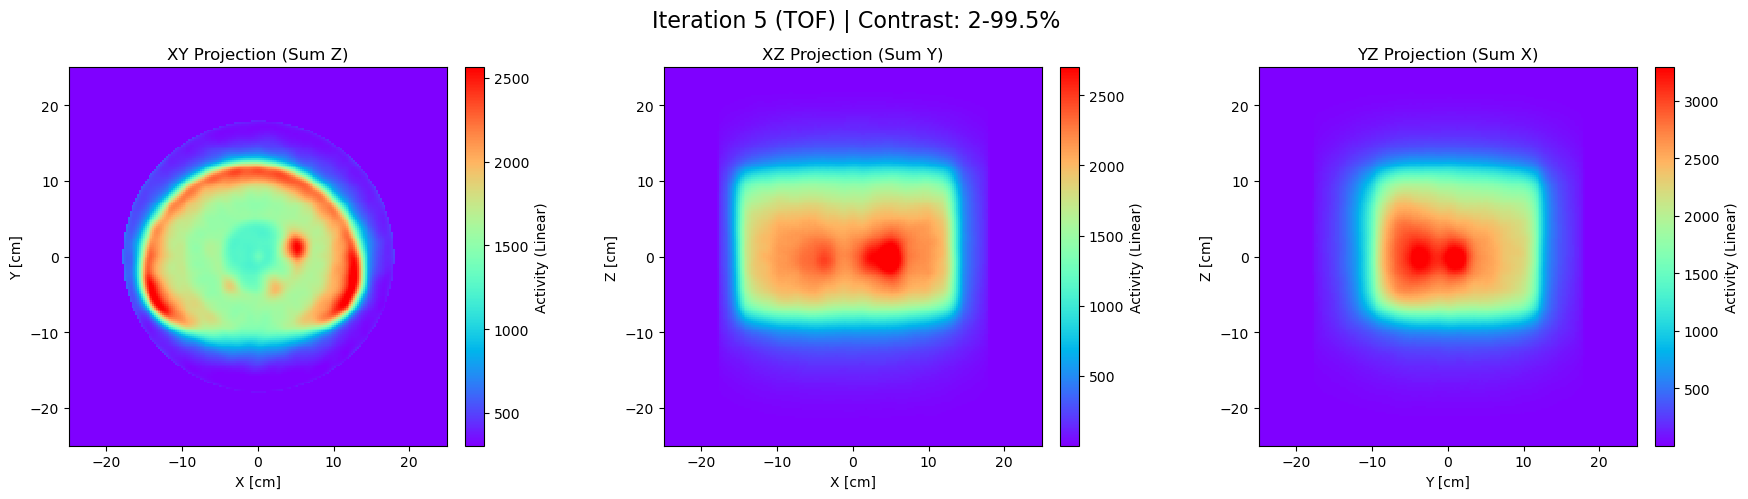

Done
  -> Iteration 6... 

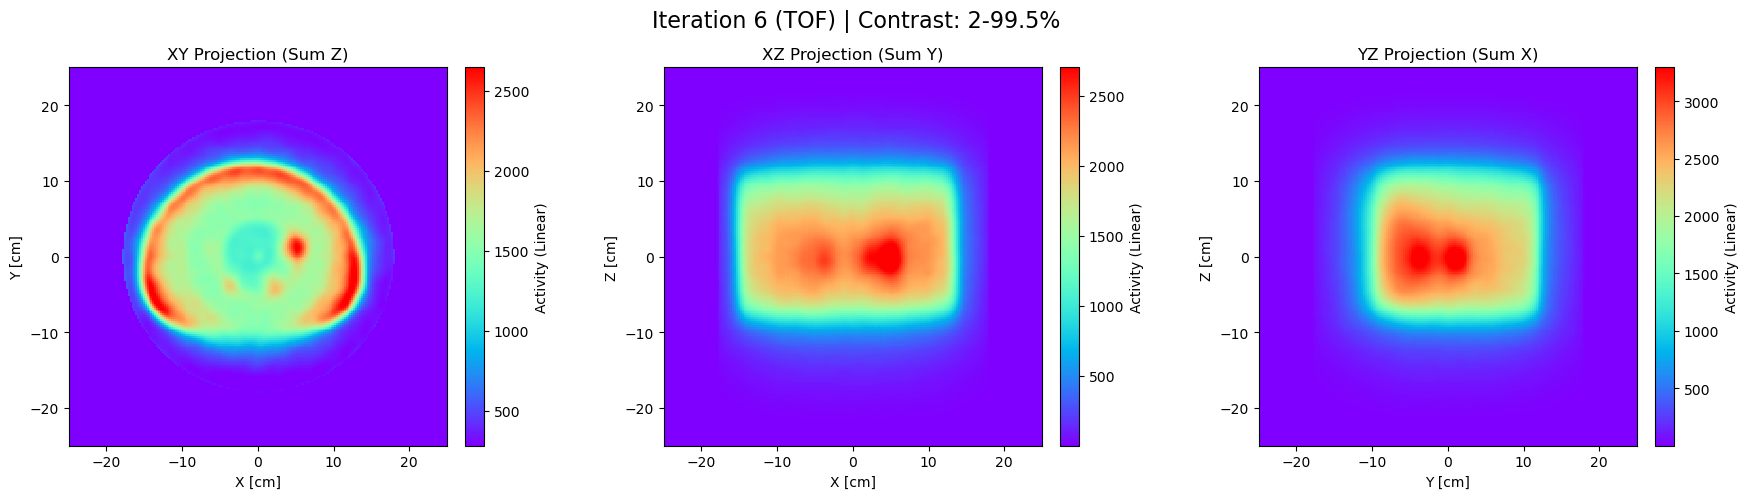

Done
  -> Iteration 7... 

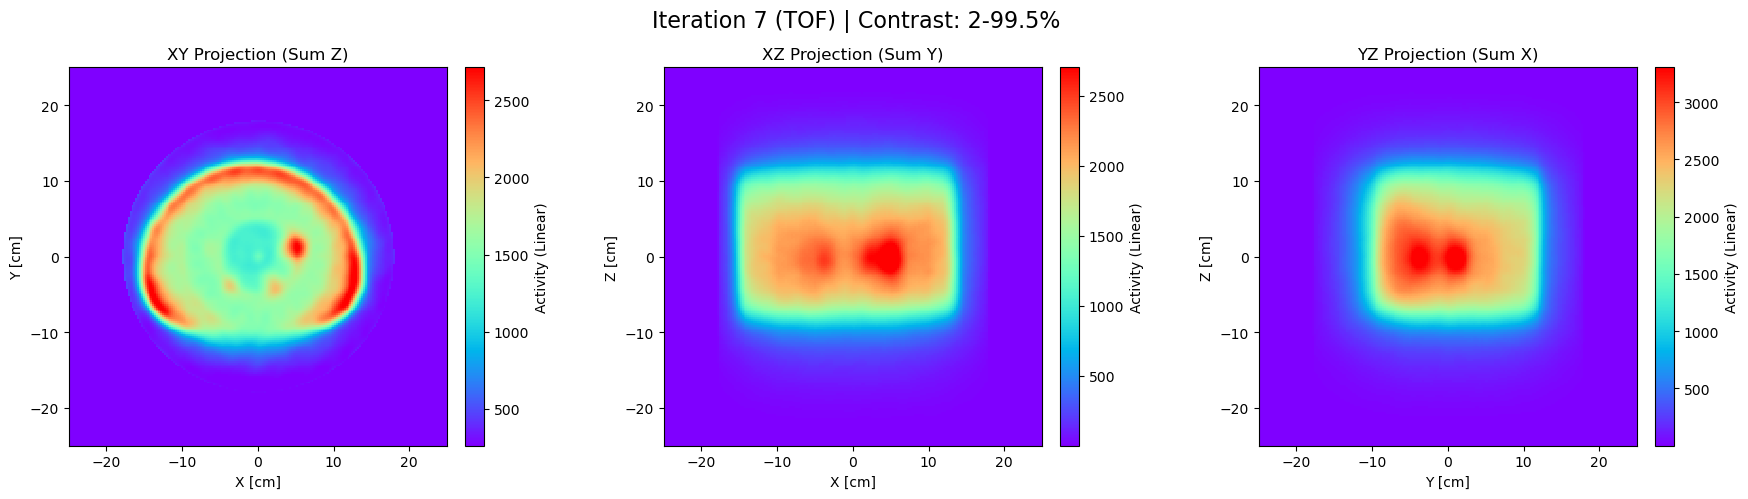

Done
  -> Iteration 8... 

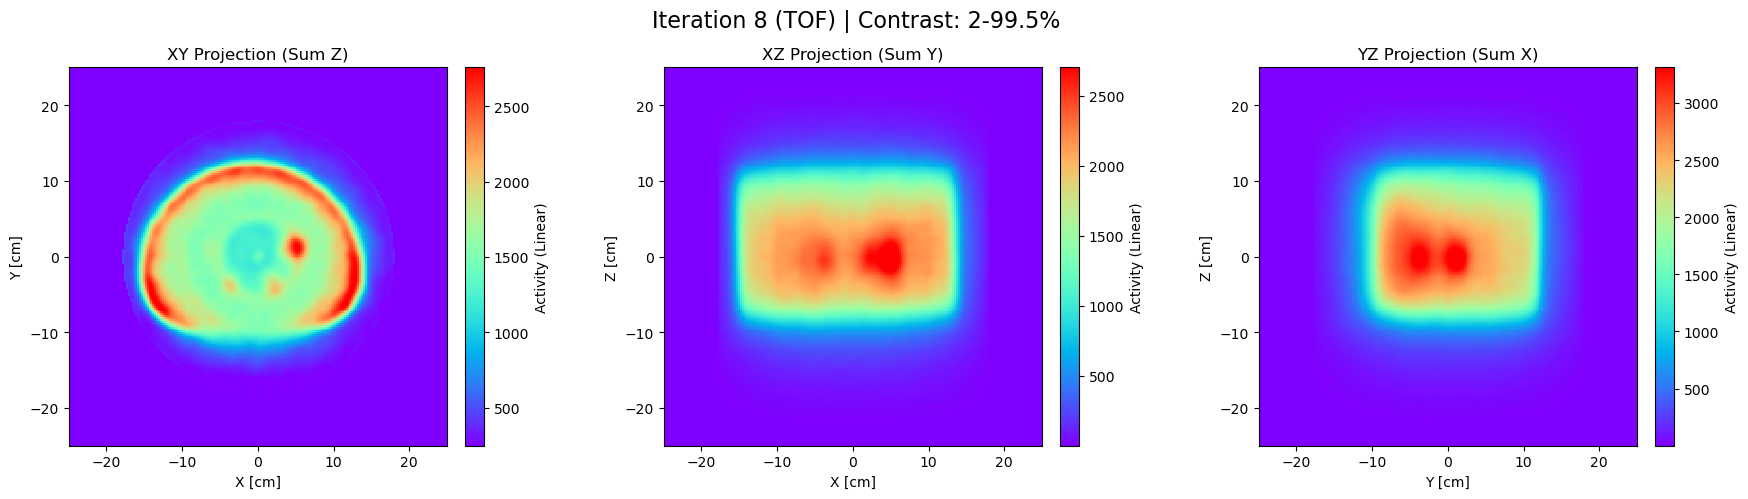

Done
  -> Iteration 9... 

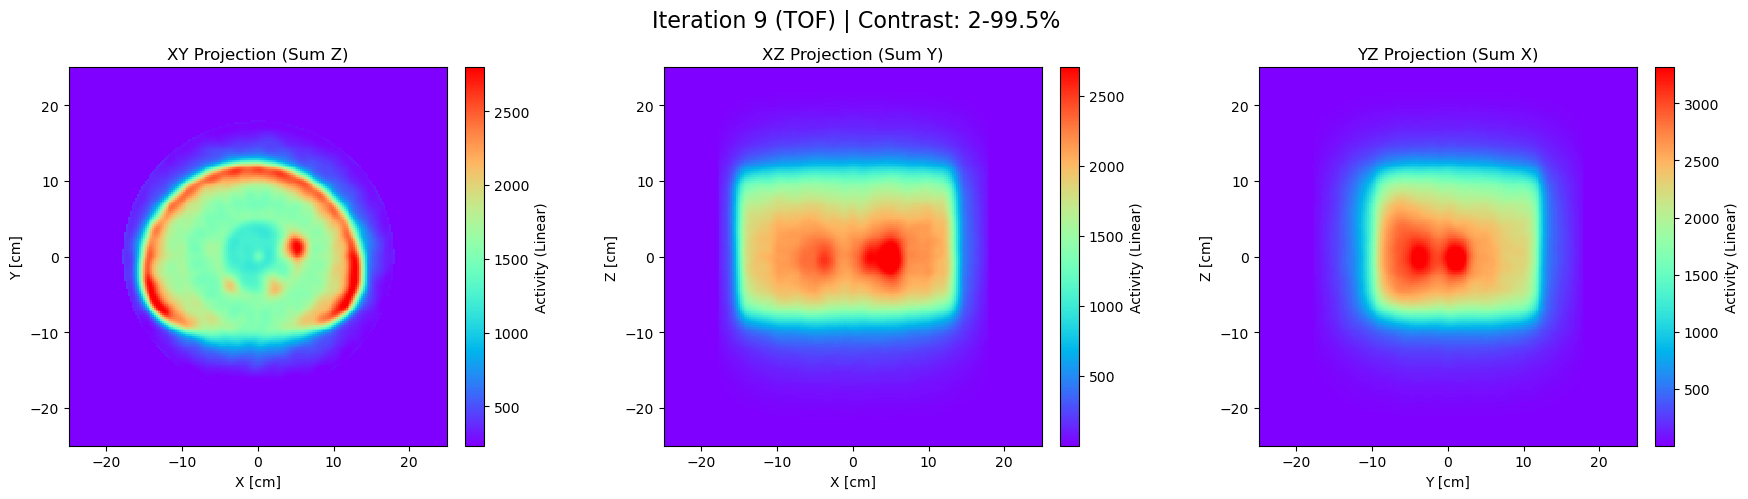

Done
  -> Iteration 10... 

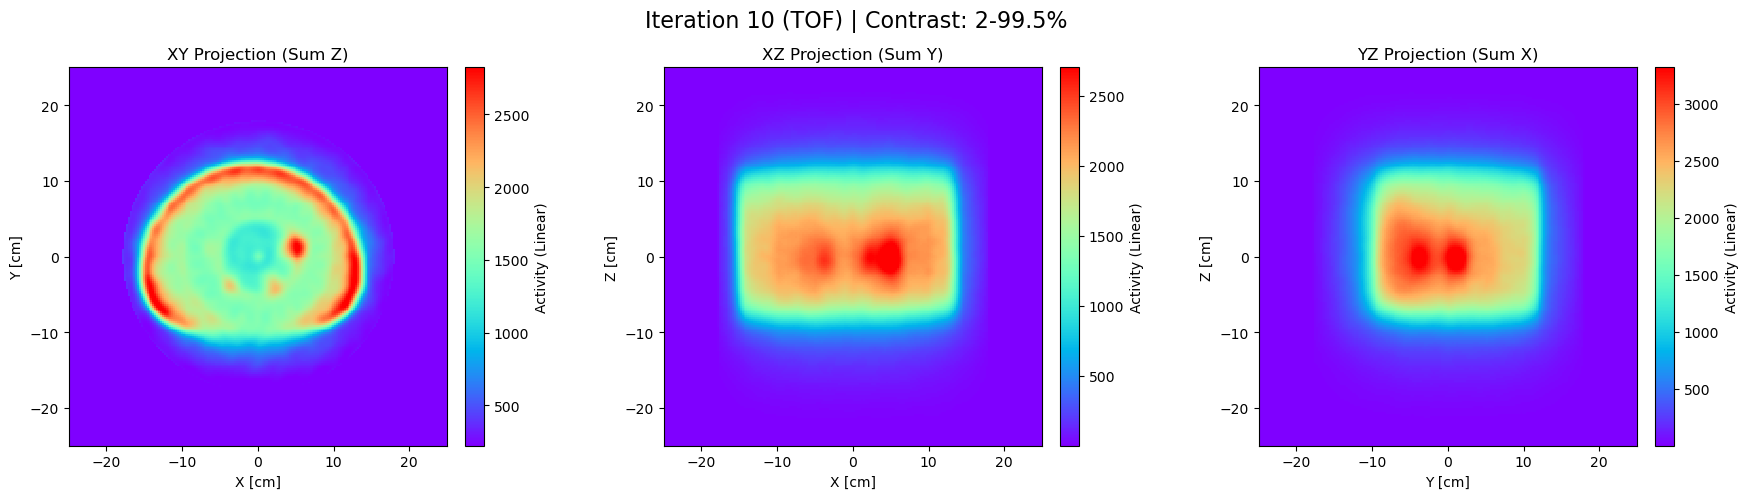

Done
  -> Iteration 11... 

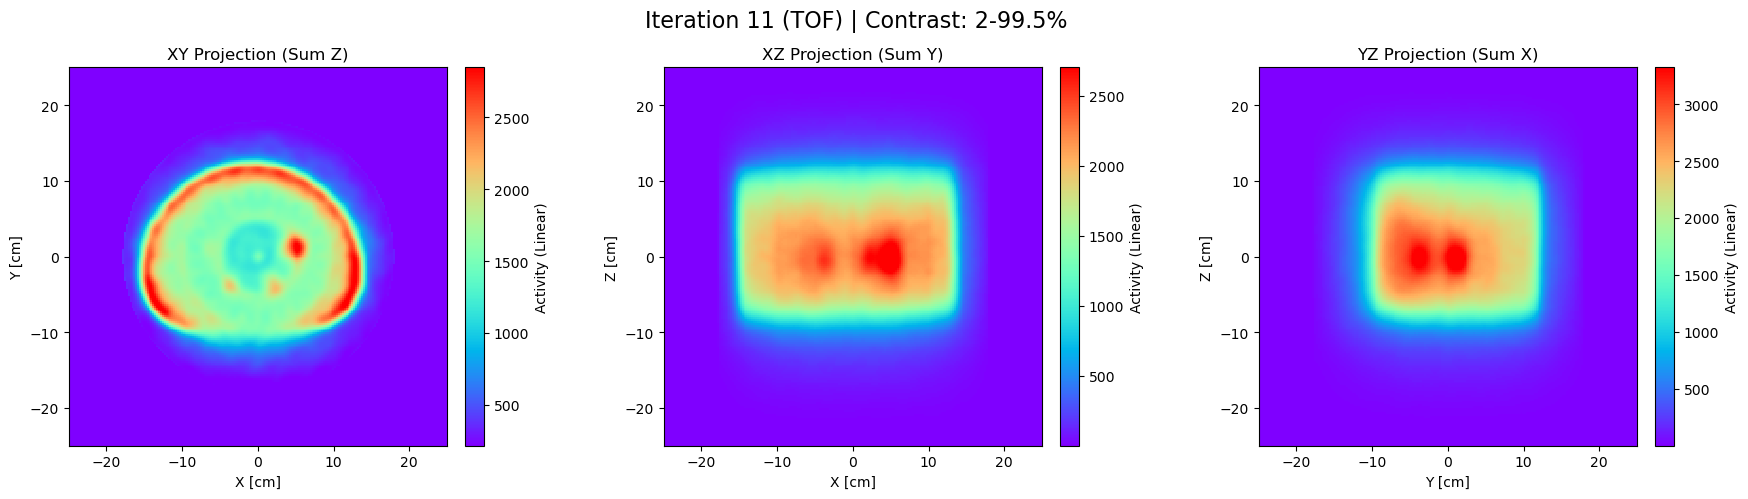

Done
  -> Iteration 12... 

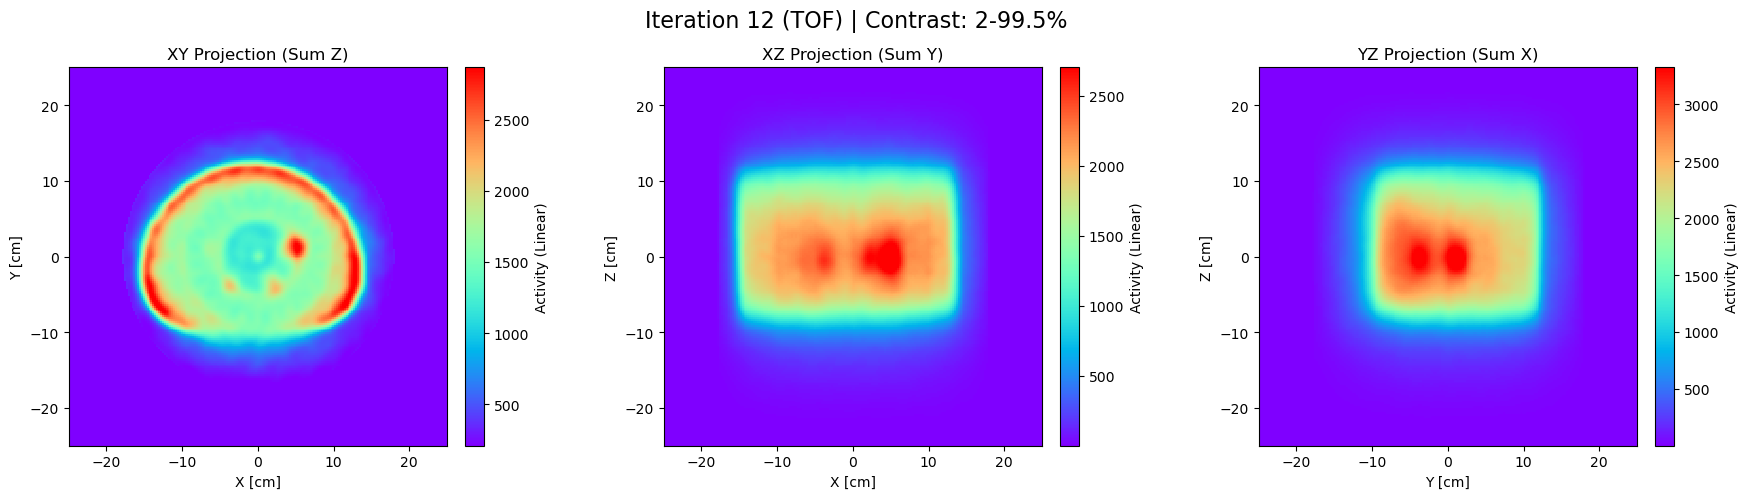

Done


In [4]:
#TESTING
import numpy as np
import uproot
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.ndimage import gaussian_filter

FILENAME = "medical.root"
TREENAME = "imaging"

N_SAMPLES = None  # None for all
N_ITERATIONS = 12    # Need less that non-tof (6-12)
STEP_SIZE = 0.2

C_LIGHT = 30.0     
TOF_RES = 0.6  #Full width at half maximum        
SIGMA_X = (C_LIGHT * TOF_RES / 2.355) / 2.0
TIME_MULT = 1e-3   

XMIN, XMAX, DX = -25.0, 25.0, 0.25
YMIN, YMAX, DY = -25.0, 25.0, 0.25
ZMIN, ZMAX, DZ = -25.0, 25.0, 0.25

Nx = int((XMAX - XMIN) / DX)
Ny = int((YMAX - YMIN) / DY)
Nz = int((ZMAX - ZMIN) / DZ)

print(f"Grid: {Nx}x{Ny}x{Nz}")
print(f"TOF Sigma X: {SIGMA_X:.3f} cm")


x_coords = np.linspace(XMIN, XMAX, Nx)
y_coords = np.linspace(YMIN, YMAX, Ny)
xx, yy = np.meshgrid(x_coords, y_coords, indexing='ij')
rr = np.sqrt(xx**2 + yy**2)


calc_mask_2d = rr < 19.5
calc_mask = np.repeat(calc_mask_2d[:, :, np.newaxis], Nz, axis=2)


display_mask_2d = rr < 18.0
display_mask = np.repeat(display_mask_2d[:, :, np.newaxis], Nz, axis=2)


N_RAYS = 10
TUBE_RADIUS = 0.24 

@njit(parallel=True, fastmath=True)
def calculate_delta(x1, y1, z1, x2, y2, z2, dt_ns, current_img):
    delta = np.zeros((Nx, Ny, Nz), dtype=np.float32)
    n_events = len(x1)
    
    for n in prange(n_events):
        vx = x2[n] - x1[n]
        vy = y2[n] - y1[n]
        vz = z2[n] - z1[n]
        L = np.sqrt(vx**2 + vy**2 + vz**2)
        if L <= 0: continue

        nx, ny, nz = vx/L, vy/L, vz/L
        steps = int(L / STEP_SIZE)
        expected_dist = (L / 2.0) - (dt_ns[n] * C_LIGHT / 2.0)

        if abs(nx) > abs(ny):
            norm_u = np.sqrt(nx**2 + nz**2)
            ux, uy, uz = -nz/norm_u, 0.0, nx/norm_u
        else:
            norm_u = np.sqrt(ny**2 + nz**2)
            ux, uy, uz = 0.0, -nz/norm_u, ny/norm_u
            
        vx_ort = ny*uz - nz*uy
        vy_ort = nz*ux - nx*uz
        vz_ort = nx*uy - ny*ux
        
        s_j_total = 0.0
        
        for r in range(N_RAYS):
            if r == 0:
                offset_u = 0.0
                offset_v = 0.0
            else:
                angle = 2.0 * np.pi * r / 9.0
                offset_u = np.cos(angle) * TUBE_RADIUS
                offset_v = np.sin(angle) * TUBE_RADIUS
                
            x1_r = x1[n] + offset_u*ux + offset_v*vx_ort
            y1_r = y1[n] + offset_u*uy + offset_v*vy_ort
            z1_r = z1[n] + offset_u*uz + offset_v*vz_ort
            
            for s in range(steps):
                dist_s = s * STEP_SIZE
                diff = dist_s - expected_dist
                weight = np.exp(- (diff**2) / (2 * SIGMA_X**2))

                curr_x = x1_r + nx * dist_s
                curr_y = y1_r + ny * dist_s
                curr_z = z1_r + nz * dist_s

                i = int((curr_x - XMIN) / DX)
                j = int((curr_y - YMIN) / DY)
                k = int((curr_z - ZMIN) / DZ)

                if 0 <= i < Nx and 0 <= j < Ny and 0 <= k < Nz:
                    s_j_total += current_img[i, j, k] * STEP_SIZE * weight

        if s_j_total < 1e-12: continue
        
        ratio = 1.0 / s_j_total

        for r in range(N_RAYS):
            if r == 0:
                offset_u = 0.0
                offset_v = 0.0
            else:
                angle = 2.0 * np.pi * r / 9.0
                offset_u = np.cos(angle) * TUBE_RADIUS
                offset_v = np.sin(angle) * TUBE_RADIUS
                
            x1_r = x1[n] + offset_u*ux + offset_v*vx_ort
            y1_r = y1[n] + offset_u*uy + offset_v*vy_ort
            z1_r = z1[n] + offset_u*uz + offset_v*vz_ort
            
            for s in range(steps):
                dist_s = s * STEP_SIZE
                diff = dist_s - expected_dist
                weight = np.exp(- (diff**2) / (2 * SIGMA_X**2))

                curr_x = x1_r + nx * dist_s
                curr_y = y1_r + ny * dist_s
                curr_z = z1_r + nz * dist_s

                i = int((curr_x - XMIN) / DX)
                j = int((curr_y - YMIN) / DY)
                k = int((curr_z - ZMIN) / DZ)

                if 0 <= i < Nx and 0 <= j < Ny and 0 <= k < Nz:
                    delta[i, j, k] += STEP_SIZE * weight * ratio

    return delta

print(f"Reading file {FILENAME}...")
with uproot.open(FILENAME) as file:
    tree = file[TREENAME]
    data = tree.arrays(
        ["X_hit1", "Y_hit1", "Z_hit1", "t_hit1",
         "X_hit2", "Y_hit2", "Z_hit2", "t_hit2"], library="np", entry_stop=N_SAMPLES)

x1, y1, z1 = data["X_hit1"].astype(np.float32), data["Y_hit1"].astype(np.float32), data["Z_hit1"].astype(np.float32)
x2, y2, z2 = data["X_hit2"].astype(np.float32), data["Y_hit2"].astype(np.float32), data["Z_hit2"].astype(np.float32)

t1_raw = data["t_hit1"].astype(np.float64)
t2_raw = data["t_hit2"].astype(np.float64)
dt_ns = ((t2_raw - t1_raw) * TIME_MULT).astype(np.float32)

print(f"Loaded: {len(x1)} events")

current_image = np.ones((Nx, Ny, Nz), dtype=np.float32)
current_image[~calc_mask] = 0.0



print(f"Starting TOF MLEM with ({N_ITERATIONS} iterations)...")


MIN_PERCENTILE = 2
MAX_PERCENTILE = 99.5

plt.ion()
for it in range(N_ITERATIONS):
    print(f"  -> Iteration {it + 1}...", end=" ")

    delta = calculate_delta(x1, y1, z1, x2, y2, z2, dt_ns, current_image)

    current_image *= (delta / sensitivity)
    current_image[~calc_mask] = 0.0

    img_corrected = current_image.copy()

    display_image = gaussian_filter(img_corrected, sigma=2)
    display_image[~display_mask] = 0.0
    
    #Beginning save block
    save_directory = r"C:\essential\subjects\Licencjat\Raw\tof_sigma2_my_own_sensmap_multi" 
    filename = f"tof iter_{it + 1:02d}.img"
    img_path = os.path.join(save_directory, filename)
    img_export = display_image.astype(np.float32)
    img_export.flatten(order='F').tofile(img_path)
    #Ending save block
    
    proj_xy = np.sum(display_image, axis=2).T
    proj_xz = np.sum(display_image, axis=1).T
    proj_yz = np.sum(display_image, axis=0).T

    plt.close('all') 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Iteration {it + 1} (TOF) | Contrast: {MIN_PERCENTILE}-{MAX_PERCENTILE}%", fontsize=16)

    def plot_projection(ax, proj_data, extent_vals, title, xlabel, ylabel):
        valid_pixels = proj_data[proj_data > 1e-10]
        if len(valid_pixels) > 0:
            vmin_val = np.percentile(valid_pixels, MIN_PERCENTILE)
            vmax_val = np.percentile(valid_pixels, MAX_PERCENTILE)
            if vmin_val <= 0: vmin_val = 0.0
        else:
            vmin_val, vmax_val = 0.0, 1.0

        im = ax.imshow(proj_data,
                       extent=extent_vals,
                       origin='lower',
                       cmap='rainbow',
                       vmin=vmin_val,
                       vmax=vmax_val,
                       interpolation='nearest')

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Activity (Linear)")

    plot_projection(axes[0], proj_xy, [XMIN, XMAX, YMIN, YMAX], "XY Projection (Sum Z)", "X [cm]", "Y [cm]")
    plot_projection(axes[1], proj_xz, [XMIN, XMAX, ZMIN, ZMAX], "XZ Projection (Sum Y)", "X [cm]", "Z [cm]")
    plot_projection(axes[2], proj_yz, [YMIN, YMAX, ZMIN, ZMAX], "YZ Projection (Sum X)", "Y [cm]", "Z [cm]")

    plt.tight_layout()
    plt.pause(0.1)
    print("Done")

plt.ioff()
plt.show()